In [3]:
import os
os.chdir(r'C:\urban-mobility-intelligence')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")

print("✅ Ready")

✅ Ready


In [5]:
import os

# Make sure we're in the right directory
os.chdir(r'C:\urban-mobility-intelligence')

# Create folders if they don't exist
os.makedirs('dashboard', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('notebooks', exist_ok=True)

print(f"✅ Working directory: {os.getcwd()}")
print(f"✅ Folders ready")

✅ Working directory: C:\urban-mobility-intelligence
✅ Folders ready


In [7]:
df = pd.read_csv('data/monthly_trips.csv.csv')

# Convert to datetime
df['trip_month'] = pd.to_datetime(df['trip_month'])

# Monthly aggregation
monthly = df.groupby('trip_month').agg(
    total_trips=('total_trips', 'sum'),
    total_revenue=('total_revenue', 'sum'),
    avg_fare=('avg_fare', 'mean'),
    avg_tip=('avg_tip', 'mean')
).reset_index()

monthly['month_label'] = monthly['trip_month'].dt.strftime('%b %Y')

print("✅ Data loaded")
print(monthly[['month_label','total_trips','total_revenue']].to_string())

✅ Data loaded
   month_label  total_trips  total_revenue
0     Jan 2001            5         145.05
1     Aug 2001            1          24.55
2     Oct 2002          342        8458.96
3     Dec 2002            2          74.61
4     Jan 2003            7         299.50
5     Dec 2008           33        1211.02
6     Jan 2009           36         878.31
7     Dec 2021           23         431.20
8     Jan 2022      2417764    46041799.91
9     Feb 2022      2926692    57245212.28
10    Mar 2022      3560164    73463810.62
11    Apr 2022      3532815    74941837.66
12    May 2022      3513657    77711063.66
13    Jun 2022      3475910    76265955.60
14    Jul 2022      3101133    66627178.97
15    Aug 2022      3075081    66422580.64
16    Sep 2022      3103246    70231283.33
17    Oct 2022      3579102    79761364.92
18    Nov 2022      3161078    69952550.13
19    Dec 2022           57        1185.16
20    Apr 2023            1          70.69


In [8]:
# Filter to 2022 only - clean out bad timestamp rows
monthly_2022 = monthly[
    (monthly['trip_month'] >= '2022-01-01') &
    (monthly['trip_month'] <= '2022-11-30')
].copy()

# Million format for readability
monthly_2022['revenue_millions'] = monthly_2022['total_revenue'] / 1e6
monthly_2022['trips_millions'] = monthly_2022['total_trips'] / 1e6

print("✅ Clean 2022 data:")
print(monthly_2022[['month_label','total_trips','total_revenue']].to_string())
print(f"\nTotal 2022 trips: {monthly_2022['total_trips'].sum():,.0f}")
print(f"Total 2022 revenue: ${monthly_2022['total_revenue'].sum()/1e6:.1f}M")

✅ Clean 2022 data:
   month_label  total_trips  total_revenue
8     Jan 2022      2417764    46041799.91
9     Feb 2022      2926692    57245212.28
10    Mar 2022      3560164    73463810.62
11    Apr 2022      3532815    74941837.66
12    May 2022      3513657    77711063.66
13    Jun 2022      3475910    76265955.60
14    Jul 2022      3101133    66627178.97
15    Aug 2022      3075081    66422580.64
16    Sep 2022      3103246    70231283.33
17    Oct 2022      3579102    79761364.92
18    Nov 2022      3161078    69952550.13

Total 2022 trips: 35,446,642
Total 2022 revenue: $758.7M


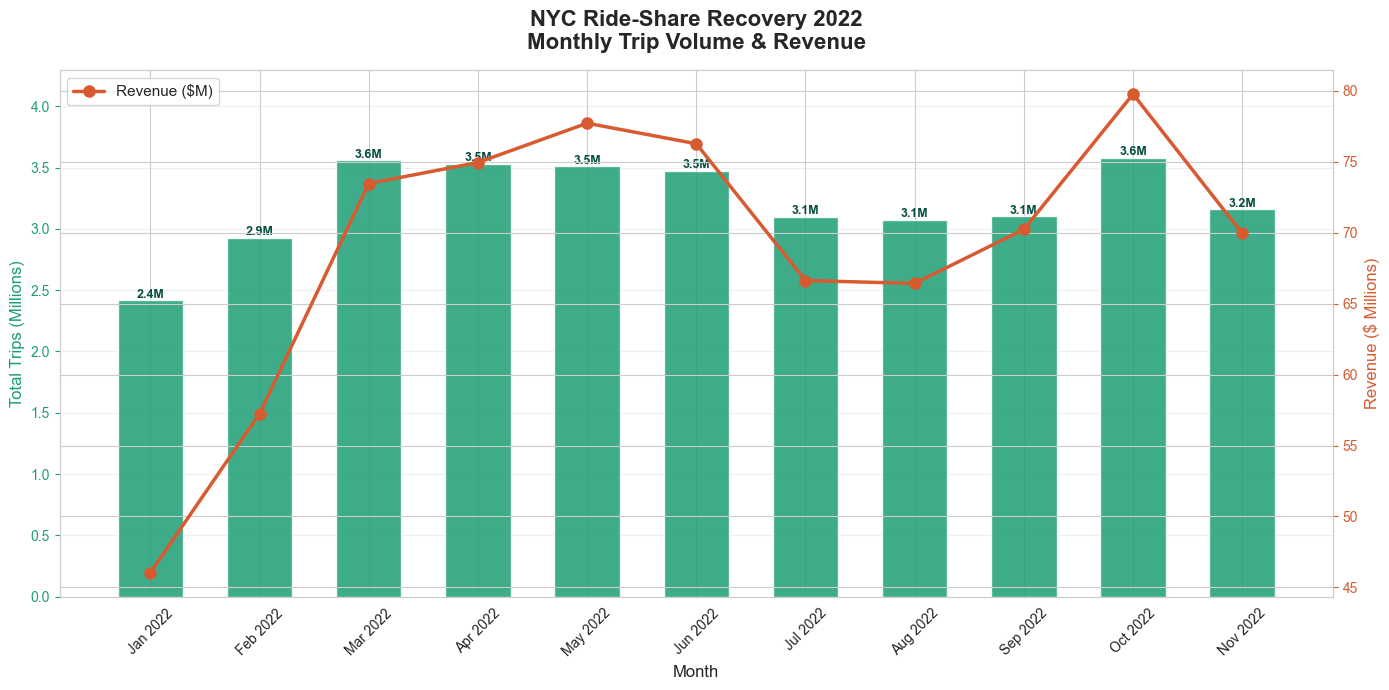

✅ Monthly trend saved!


In [9]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Trip volume bars
bars = ax1.bar(monthly_2022['month_label'],
               monthly_2022['trips_millions'],
               color='#1D9E75', alpha=0.85, width=0.6, zorder=3)

# Revenue line overlay
ax2 = ax1.twinx()
ax2.plot(monthly_2022['month_label'],
         monthly_2022['revenue_millions'],
         color='#D85A30', marker='o', linewidth=2.5,
         markersize=8, label='Revenue ($M)', zorder=4)

# Labels on bars
for bar, val in zip(bars, monthly_2022['trips_millions']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.1f}M', ha='center',
             fontsize=9, fontweight='bold', color='#085041')

ax1.set_title('NYC Ride-Share Recovery 2022\nMonthly Trip Volume & Revenue',
              fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Trips (Millions)', fontsize=12, color='#1D9E75')
ax1.tick_params(axis='y', colors='#1D9E75')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(0, monthly_2022['trips_millions'].max() * 1.2)
ax1.grid(axis='y', alpha=0.3, zorder=0)

ax2.set_ylabel('Revenue ($ Millions)', fontsize=12, color='#D85A30')
ax2.tick_params(axis='y', colors='#D85A30')
ax2.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('dashboard/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Monthly trend saved!")

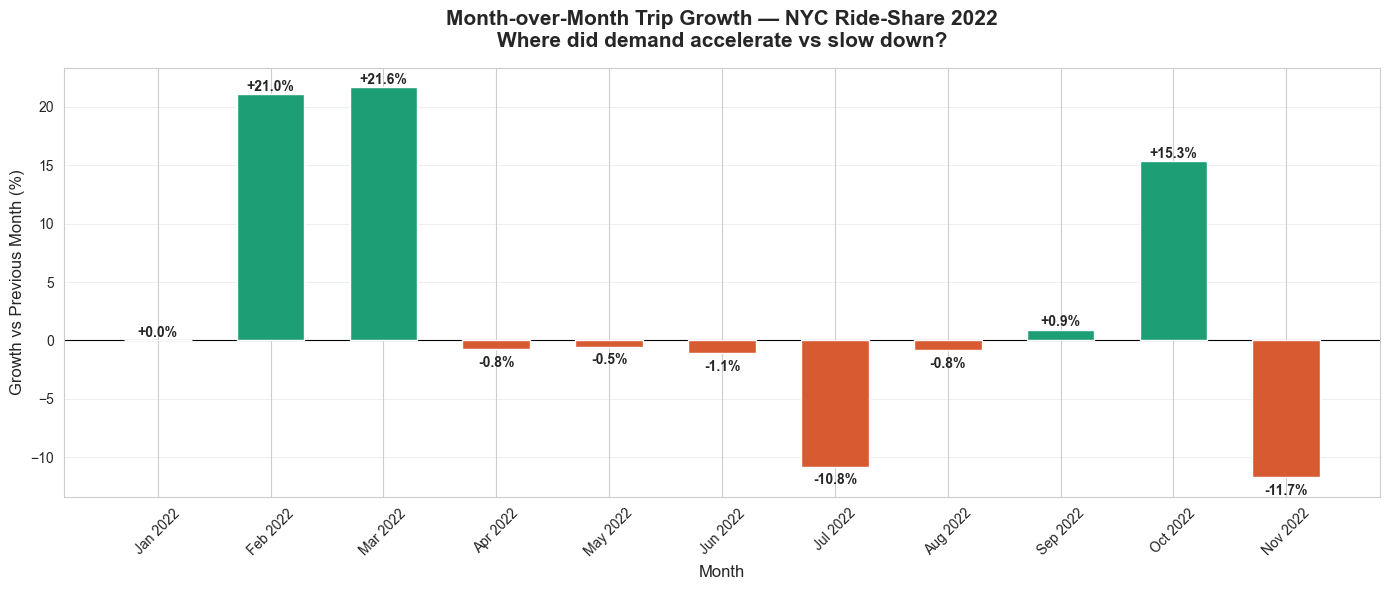

✅ MoM growth chart saved!


In [10]:
monthly_2022['trip_growth_pct'] = monthly_2022['total_trips'].pct_change() * 100
monthly_2022['rev_growth_pct'] = monthly_2022['total_revenue'].pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1D9E75' if x >= 0 else '#D85A30'
          for x in monthly_2022['trip_growth_pct'].fillna(0)]

bars = ax.bar(monthly_2022['month_label'],
              monthly_2022['trip_growth_pct'].fillna(0),
              color=colors, width=0.6, zorder=3)

# Value labels
for bar, val in zip(bars, monthly_2022['trip_growth_pct'].fillna(0)):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.1f}%', ha='center',
            fontsize=10, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax.set_title('Month-over-Month Trip Growth — NYC Ride-Share 2022\nWhere did demand accelerate vs slow down?',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Growth vs Previous Month (%)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('dashboard/mom_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ MoM growth chart saved!")

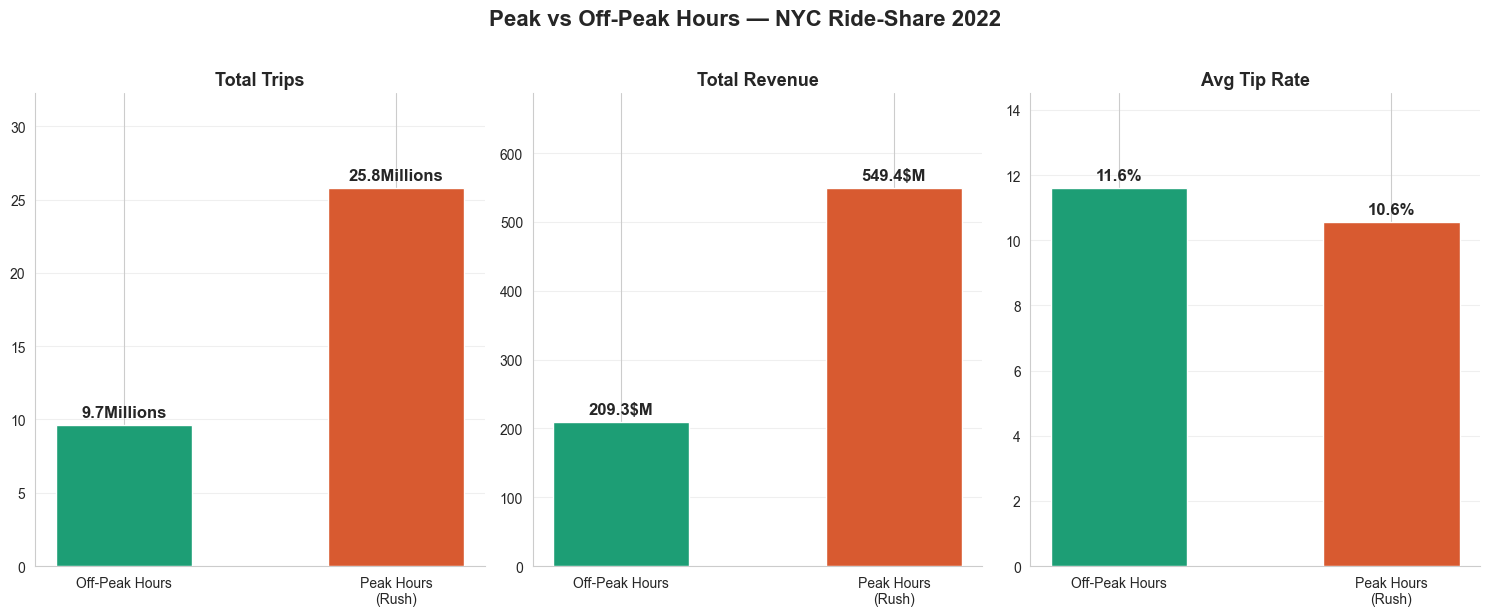

✅ Peak vs off-peak chart saved!


In [12]:
# Peak vs Off-Peak analysis from segments data
# Ensure 'segments' exists and has required columns for peak analysis
if 'segments' not in globals():
    segments = df.copy()
    # tip rate as percentage (safe division)
    segments['tip_rate_pct'] = np.where(
        segments['avg_fare'] > 0,
        segments['avg_tip'] / segments['avg_fare'] * 100,
        0.0
    )
    # Simple heuristic to create time segments (placeholder)
    def _time_segment(month_num):
        if month_num in (1, 2, 3, 4, 5):
            return 'Morning Rush'
        if month_num in (9, 10, 11):
            return 'Evening Rush'
        return 'Off-Peak'
    segments['time_segment'] = segments['trip_month_num'].apply(_time_segment)

peak_analysis = segments.copy()

# Categorise into peak vs off-peak
peak_analysis['is_peak'] = peak_analysis['time_segment'].isin(
    ['Morning Rush', 'Evening Rush']
)

peak_summary = peak_analysis.groupby('is_peak').agg(
    total_trips=('total_trips', 'sum'),
    total_revenue=('total_revenue', 'sum'),
    avg_fare=('avg_fare', 'mean'),
    avg_tip_rate=('tip_rate_pct', 'mean')
).reset_index()

peak_summary['label'] = peak_summary['is_peak'].map(
    {True: 'Peak Hours\n(Rush)', False: 'Off-Peak Hours'}
)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Peak vs Off-Peak Hours — NYC Ride-Share 2022',
             fontsize=16, fontweight='bold', y=1.02)

metrics = [
    ('total_trips', 'Total Trips', '1e6', 'Millions'),
    ('total_revenue', 'Total Revenue', '1e6', '$M'),
    ('avg_tip_rate', 'Avg Tip Rate', '1', '%'),
]

colors_peak = ['#1D9E75', '#D85A30']

for ax, (col, title, divisor, unit) in zip(axes, metrics):
    vals = peak_summary[col] / float(divisor)
    bars = ax.bar(peak_summary['label'], vals,
                  color=colors_peak, width=0.5, zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + vals.max()*0.02,
                f'{val:.1f}{unit}', ha='center',
                fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, vals.max() * 1.25)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('dashboard/peak_vs_offpeak.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Peak vs off-peak chart saved!")